In [1]:
from pathlib import Path
import math

import geopandas as gpd
import numpy as np
import rasterio
from rasterio.mask import mask
from shapely.geometry import box
from shapely.affinity import scale  # <-- NEW
from scipy.ndimage import rotate
from skimage.transform import resize


# ============================================================
# CONFIG
# ============================================================
DATA_DIR = Path("PBM_1.7.2_datasetsM172_RGB_MS").resolve()

RGB_TIF = DATA_DIR / "UAV_2306_RGB_barley_plots.tif"
MSP_TIF = DATA_DIR / "UAV_2306_MSP_barley_plots.tif"
GEOJSON = "plots_final.geojson"   # or DATA_DIR / "plot2.geojson"

OUTPUT_DIR = DATA_DIR / "microplots_output"
OUTPUT_DIR.mkdir(exist_ok=True)

SAVE_RGB = True
SAVE_MSP = True
SAVE_STACK = True

# Which image to use as reference grid for the stack?
STACK_REF = "msp"    # "rgb" or "msp"
PLOT_ID_FIELD = "id"

# NEW: how much of the *central* part of the plot to keep, in percent.
# 100.0 = full polygon, 50.0 = central half (in width & height).
CENTER_PERCENT = 60.0


# ============================================================
# UTILITIES
# ============================================================
def read_geojson(path: str | Path) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(path)
    if gdf.empty:
        raise ValueError(f"GeoJSON '{path}' has no features.")
    return gdf


def compute_polygon_main_angle(poly) -> float:
    """Compute plot orientation angle from minimum rotated rectangle."""
    mrr = poly.minimum_rotated_rectangle
    coords = list(mrr.exterior.coords)

    best_len = 0
    best_edge = None

    for i in range(4):
        x1, y1 = coords[i]
        x2, y2 = coords[i + 1]
        dx = x2 - x1
        dy = y2 - y1
        L = math.hypot(dx, dy)
        if L > best_len:
            best_len = L
            best_edge = (dx, dy)

    dx, dy = best_edge
    angle = math.degrees(math.atan2(dy, dx))
    return angle


def shrink_polygon_to_center(poly, percent: float):
    """
    Shrink polygon toward its centroid, keeping a central fraction of width/height.

    percent: 0 < percent <= 100
        100 = original polygon
        50  = central half (in both x and y)
    """
    if not (0 < percent <= 100):
        raise ValueError("percent must be in (0, 100].")

    factor = percent / 100.0
    return scale(poly, xfact=factor, yfact=factor, origin="centroid")


def crop_raster(
    src: rasterio.io.DatasetReader,
    poly,
    center_percent: float | None = None,
):
    """
    Crop a raster with a polygon. Returns array (bands, H, W).

    center_percent:
        If provided, the polygon is shrunk toward its centroid before cropping.
        Example: 60.0 keeps ~60% central width & height.
    """
    if center_percent is not None:
        poly = shrink_polygon_to_center(poly, center_percent)

    if not poly.intersects(box(*src.bounds)):
        raise ValueError("Polygon does not overlap raster.")

    arr, transform = mask(
        src,
        [poly.__geo_interface__],
        crop=True,
        filled=True,
        nodata=0,
    )
    return arr, transform


def rotate_image(image: np.ndarray, angle: float) -> np.ndarray:
    """Rotate (C, H, W) by angle (deg, CCW), keep maximal rotated size."""
    img_rot = rotate(
        image,
        angle=angle,
        axes=(1, 2),
        reshape=True,
        order=1,
    )
    return img_rot


def resize_to_match(source: np.ndarray, target_shape: tuple[int, int]) -> np.ndarray:
    """
    Resize a (C, H, W) source to (C, Ht, Wt) given target spatial shape (Ht, Wt).
    """
    C, H, W = source.shape
    Ht, Wt = target_shape
    if (H, W) == (Ht, Wt):
        return source

    out = np.zeros((C, Ht, Wt), dtype=np.float32)
    for b in range(C):
        out[b] = resize(
            source[b],
            (Ht, Wt),
            preserve_range=True,
            anti_aliasing=True,
        )
    return out


def get_plot_name(row, idx: int) -> str:
    """
    Build a plot name from a GeoDataFrame row + fallback index.
    Uses PLOT_ID_FIELD if present, otherwise 'plot_{idx:03d}'.
    """
    if PLOT_ID_FIELD in row and row[PLOT_ID_FIELD] not in (None, ""):
        raw = str(row[PLOT_ID_FIELD])
        # very simple sanitization for filenames
        safe = "".join(
            c if c.isalnum() or c in ("-", "_") else "_"
            for c in raw
        )
        return safe
    else:
        return f"plot_{idx:03d}"


# ============================================================
# MAIN PIPELINE
# ============================================================
if __name__ == "__main__":
    gdf = read_geojson(GEOJSON)

    # Create output dirs
    (OUTPUT_DIR / "rgb").mkdir(exist_ok=True)
    (OUTPUT_DIR / "msp").mkdir(exist_ok=True)
    (OUTPUT_DIR / "stack").mkdir(exist_ok=True)

    with rasterio.open(RGB_TIF) as rgb_src, rasterio.open(MSP_TIF) as msp_src:

        # GeoJSON in RGB CRS
        if gdf.crs != rgb_src.crs:
            gdf_rgb = gdf.to_crs(rgb_src.crs)
        else:
            gdf_rgb = gdf

        # GeoJSON in MSP CRS
        gdf_msp = gdf_rgb.to_crs(msp_src.crs)

        print(f"Total polygons: {len(gdf_rgb)}")

        for idx in range(len(gdf_rgb)):
            row_rgb = gdf_rgb.iloc[idx]
            plot_name = get_plot_name(row_rgb, idx)
            print(f"\n=== Plot {idx} (name: {plot_name}) ===")

            poly_rgb = row_rgb.geometry
            poly_msp = gdf_msp.geometry[idx]

            # 1. Crop RGB & MSP (central part of the polygon)
            try:
                rgb_crop, _ = crop_raster(
                    rgb_src,
                    poly_rgb,
                    center_percent=CENTER_PERCENT,
                )   # (3, Hr, Wr)
                msp_crop, _ = crop_raster(
                    msp_src,
                    poly_msp,
                    center_percent=CENTER_PERCENT,
                )   # (Cmsp, Hm, Wm)
            except Exception as e:
                print(f"  ERROR cropping idx {idx}: {e}")
                continue

            # 2. Compute rotation angle (from polygon in RGB CRS)
            angle = -compute_polygon_main_angle(poly_rgb)
            print(f"  Rotation applied: {angle:.2f}°")

            # 3. Rotate each independently, KEEPING maximal size
            rgb_rot = rotate_image(rgb_crop, angle)
            msp_rot = rotate_image(msp_crop, angle)

            print("  Rotated RGB shape:", rgb_rot.shape)
            print("  Rotated MSP shape:", msp_rot.shape)

            # 4. Save RGB and MSP at their own maximal sizes
            if SAVE_RGB:
                np.save(OUTPUT_DIR / "rgb" / f"{plot_name}_rgb.npy", rgb_rot)
            if SAVE_MSP:
                np.save(OUTPUT_DIR / "msp" / f"{plot_name}_msp.npy", msp_rot)

            # 5. Build stack on a common grid
            if SAVE_STACK:
                if STACK_REF == "rgb":
                    ref = "rgb"
                    Ht, Wt = rgb_rot.shape[1:]
                    rgb_for_stack = rgb_rot.astype(np.float32)
                    msp_for_stack = resize_to_match(msp_rot, (Ht, Wt)).astype(np.float32)
                else:
                    ref = "msp"
                    Ht, Wt = msp_rot.shape[1:]
                    msp_for_stack = msp_rot.astype(np.float32)
                    rgb_for_stack = resize_to_match(rgb_rot, (Ht, Wt)).astype(np.float32)

                stacked = np.concatenate(
                    [rgb_for_stack, msp_for_stack],
                    axis=0,
                )

                print(f"  Stack reference: {ref}, stacked shape: {stacked.shape}")
                np.save(OUTPUT_DIR / "stack" / f"{plot_name}_stack.npy", stacked)

            print("  Saved.")


C:\Users\bonte\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:198: RuntimeWarning: Several features with id = 56 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


Total polygons: 40

=== Plot 0 (name: 1) ===
  Rotation applied: -110.67°
  Rotated RGB shape: (3, 1729, 1936)
  Rotated MSP shape: (5, 843, 944)
  Stack reference: msp, stacked shape: (8, 843, 944)
  Saved.

=== Plot 1 (name: 2) ===
  Rotation applied: 68.24°
  Rotated RGB shape: (3, 1755, 1974)
  Rotated MSP shape: (5, 857, 964)
  Stack reference: msp, stacked shape: (8, 857, 964)
  Saved.

=== Plot 2 (name: 3) ===
  Rotation applied: -111.40°
  Rotated RGB shape: (3, 1725, 1958)
  Rotated MSP shape: (5, 842, 956)
  Stack reference: msp, stacked shape: (8, 842, 956)
  Saved.

=== Plot 3 (name: 4) ===
  Rotation applied: -111.39°
  Rotated RGB shape: (3, 1709, 1901)
  Rotated MSP shape: (5, 834, 927)
  Stack reference: msp, stacked shape: (8, 834, 927)
  Saved.

=== Plot 4 (name: 5) ===
  Rotation applied: 69.61°
  Rotated RGB shape: (3, 1654, 1860)
  Rotated MSP shape: (5, 807, 908)
  Stack reference: msp, stacked shape: (8, 807, 908)
  Saved.

=== Plot 5 (name: 56) ===
  Rotation ap

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm  # instead of from tqdm import tqdm


# ============================================================
# CONFIG
# ============================================================
DATA_DIR = Path("PBM_1.7.2_datasetsM172_RGB_MS").resolve()
OUTPUT_DIR = DATA_DIR / "microplots_output"
STACK_DIR = OUTPUT_DIR / "stack"

INDEX_DIR = OUTPUT_DIR / "indices"
INDEX_DIR.mkdir(exist_ok=True)

SAVE_INDEX_MAPS = True   # set False if you only care about stats

# Stack layout
# 0: R (RGB)
# 1: G (RGB)
# 2: B (RGB)
# 3: Blue   (MSP)
# 4: Green  (MSP)
# 5: Red    (MSP)
# 6: RedEdge(MSP)
# 7: NIR    (MSP)
RGB_BANDS = 3
MSP_OFFSET = RGB_BANDS

# DJI-like MSP order: Blue, Green, Red, RedEdge, NIR
MSP_BAND_INDEX = {
    "blue": 0,
    "green": 1,
    "red": 2,
    "red_edge": 3,
    "nir": 4,
}

# Convert MSP band index to stack channel index
STACK_BAND_INDEX = {
    name: MSP_OFFSET + idx for name, idx in MSP_BAND_INDEX.items()
}

# ============================================================
# INDEX DEFINITIONS (add/remove indices here)
# Each function takes a dict "b" with keys: blue, green, red, red_edge, nir
# and returns a 2D array (H, W)
# ============================================================
def safe_ratio(num: np.ndarray, den: np.ndarray) -> np.ndarray:
    num = num.astype(np.float32)
    den = den.astype(np.float32)
    with np.errstate(divide="ignore", invalid="ignore"):
        out = num / den
        out[~np.isfinite(out)] = np.nan
    return out


def idx_ndvi(b):
    # NDVI = (NIR - Red) / (NIR + Red)
    return safe_ratio(b["nir"] - b["red"], b["nir"] + b["red"])


def idx_ndre(b):
    # NDRE = (NIR - RedEdge) / (NIR + RedEdge)
    return safe_ratio(b["nir"] - b["red_edge"], b["nir"] + b["red_edge"])


def idx_gndvi(b):
    # GNDVI = (NIR - Green) / (NIR + Green)
    return safe_ratio(b["nir"] - b["green"], b["nir"] + b["green"])


def idx_osavi(b, L: float = 0.16):
    # OSAVI = (1 + L) * (NIR - Red) / (NIR + Red + L)
    return (1.0 + L) * safe_ratio(b["nir"] - b["red"], b["nir"] + b["red"] + L)


def idx_savi(b, L=0.5):
    # SAVI = (NIR - Red) * (1 + L) / (NIR + Red + L)
    return (b["nir"] - b["red"]) * (1 + L) / (b["nir"] + b["red"] + L)


def idx_msavi(b):
    nir = b["nir"].astype(np.float32)
    red = b["red"].astype(np.float32)
    return (2 * nir + 1 - np.sqrt((2 * nir + 1)**2 - 8 * (nir - red))) / 2


def idx_evi(b):
    # EVI = 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)
    return 2.5 * (b["nir"] - b["red"]) / (b["nir"] + 6*b["red"] - 7.5*b["blue"] + 1)


def idx_evi2(b):
    # EVI2 = 2.5 * (NIR - Red) / (NIR + 2.4*Red + 1)
    return 2.5 * (b["nir"] - b["red"]) / (b["nir"] + 2.4 * b["red"] + 1)


def idx_ndwi(b):
    # NDWI = (Green - NIR) / (Green + NIR)
    return safe_ratio(b["green"] - b["nir"], b["green"] + b["nir"])

def idx_ndmi(b):
    # NDMI (here using NIR and RedEdge)
    return safe_ratio(b["nir"] - b["red_edge"], b["nir"] + b["red_edge"])

def idx_vari(b):
    # VARI = (Green - Red) / (Green + Red - Blue)
    return safe_ratio(b["green"] - b["red"], b["green"] + b["red"] - b["blue"])


def idx_mcari(b):
    # MCARI = (RedEdge - Red) - 0.2 * (RedEdge - Green)
    return (b["red_edge"] - b["red"]) - 0.2 * (b["red_edge"] - b["green"])


def idx_mtvi2(b):
    # MTVI2
    nir = b["nir"]
    red = b["red"]
    green = b["green"]
    return (1.5 * (1.2 * (nir - green) - 2.5 * (red - green))) / np.sqrt(
        (2*nir + 1)**2 - (6*nir - 5*np.sqrt(red)) - 0.5
    )


INDEX_FUNCS = {
    "ndvi": idx_ndvi,
    "ndre": idx_ndre,
    "gndvi": idx_gndvi,
    "osavi": lambda b: idx_osavi(b, L=0.16),

    # New ones:
    "savi": lambda b: idx_savi(b, L=0.5),
    "msavi": idx_msavi,
    "evi": idx_evi,
    "evi2": idx_evi2,
    "ndwi": idx_ndwi,
    "ndmi": idx_ndmi,
    "vari": idx_vari,
    "mcari": idx_mcari,
    "mtvi2": idx_mtvi2,
}

# Stats we want for each index
STATS = ["mean", "median", "min", "max", "std"]


# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    stack_files = sorted(STACK_DIR.glob("*.npy"))
    print(f"Found {len(stack_files)} stacked microplots.")

    rows = []

    # Use tqdm for progress bar
    for path in tqdm(stack_files, desc="Processing microplots", dynamic_ncols=True, leave=True, mininterval=0.5):

        base_name = path.name.replace("_stack.npy", "")

        cube = np.load(path)  # shape: (C, H, W)
        C, H, W = cube.shape
        tqdm.write(str(f"Processing {path.name}"+f"  Stack shape: {cube.shape}"))
        # Build band dict (b["nir"], b["red"], etc.)
        bands = {}
        missing_bands = []
        for name, ch in STACK_BAND_INDEX.items():
            if ch >= C:
                missing_bands.append(name)
            else:
                bands[name] = cube[ch]

        if missing_bands:
            tqdm.write(f"  WARNING: missing bands {missing_bands} in {base_name}, skipping.")
            continue

        # Valid mask: exclude pure padding/nodata
        # Simple heuristic: sum of key bands > 0
        key_for_valid = ["nir", "red", "red_edge", "green"]
        valid = np.zeros((H, W), dtype=bool)
        for k in key_for_valid:
            valid |= (bands[k] > 0)

        if not np.any(valid):
            tqdm.write("  WARNING: no valid pixels, skipping stats.")
            continue

        # Prepare row with base info
        try:
            numeric_id = int(base_name.split("_")[-1])
        except Exception:
            numeric_id = None

        row = {
            "plot_name": base_name,
            "plot_id": numeric_id,
        }

        # Compute all indices and stats
        for idx_name, func in INDEX_FUNCS.items():
            idx_map = func(bands)  # (H, W) with NaNs possible

            # Optionally save the full index map
            if SAVE_INDEX_MAPS:
                np.save(
                    INDEX_DIR / f"{base_name}_{idx_name}.npy",
                    idx_map.astype(np.float32),
                )

            # restrict to valid pixels + finite values
            data = idx_map[valid]
            data = data[np.isfinite(data)]
            if data.size == 0:
                stats_values = {
                    "mean": np.nan,
                    "median": np.nan,
                    "min": np.nan,
                    "max": np.nan,
                    "std": np.nan,
                }
            else:
                stats_values = {
                    "mean": float(np.mean(data)),
                    "median": float(np.median(data)),
                    "min": float(np.min(data)),
                    "max": float(np.max(data)),
                    "std": float(np.std(data, ddof=1)) if data.size > 1 else 0.0,
                }

            # Store stats in the row with flattened names: index_stat
            for stat_name, value in stats_values.items():
                col_name = f"{idx_name}_{stat_name}"
                row[col_name] = value

        rows.append(row)

    # Build and save summary DataFrame
    df = pd.DataFrame(rows)
    csv_path = INDEX_DIR / "microplots_indices_summary.csv"
    df.to_csv(csv_path, index=False)
    print(f"\nSaved summary CSV to: {csv_path}")


Found 39 stacked microplots.


Processing microplots:   0%|          | 0/39 [00:00<?, ?it/s]

Processing 11_stack.npy  Stack shape: (8, 831, 944)
Processing 12_stack.npy  Stack shape: (8, 831, 935)
Processing 13_stack.npy  Stack shape: (8, 836, 946)
Processing 14_stack.npy  Stack shape: (8, 823, 934)
Processing 15_stack.npy  Stack shape: (8, 838, 940)
Processing 16_stack.npy  Stack shape: (8, 835, 930)
Processing 17_stack.npy  Stack shape: (8, 835, 926)
Processing 18_stack.npy  Stack shape: (8, 824, 923)
Processing 1_stack.npy  Stack shape: (8, 843, 944)
Processing 21_stack.npy  Stack shape: (8, 835, 939)
Processing 22_stack.npy  Stack shape: (8, 861, 955)
Processing 23_stack.npy  Stack shape: (8, 859, 960)
Processing 24_stack.npy  Stack shape: (8, 851, 946)
Processing 25_stack.npy  Stack shape: (8, 823, 934)
Processing 26_stack.npy  Stack shape: (8, 837, 931)
Processing 27_stack.npy  Stack shape: (8, 832, 937)
Processing 28_stack.npy  Stack shape: (8, 866, 962)
Processing 2_stack.npy  Stack shape: (8, 857, 964)
Processing 31_stack.npy  Stack shape: (8, 843, 944)
Processing 32_

In [3]:
df

,plot_name,plot_id,ndvi_mean,ndvi_median,ndvi_min,ndvi_max,ndvi_std,ndre_mean,ndre_median,ndre_min,...,mcari_mean,mcari_median,mcari_min,mcari_max,mcari_std,mtvi2_mean,mtvi2_median,mtvi2_min,mtvi2_max,mtvi2_std
0,11,11,0.900256,0.904500,0.593558,0.959087,0.024845,0.474921,0.478812,0.198704,...,0.013882,0.013828,2.216661e-06,0.025745,0.002257,0.123806,0.127124,2.498859e-05,0.182269,0.018961
1,12,12,0.858642,0.870642,0.521405,0.955318,0.053223,0.372535,0.373408,0.113298,...,0.016034,0.016004,9.681434e-06,0.028065,0.002446,0.111012,0.112595,9.305121e-05,0.164454,0.018274
2,13,13,0.909122,0.914952,0.471656,0.967311,0.031167,0.483939,0.487566,0.183920,...,0.013227,0.013183,4.227280e-07,0.024346,0.002235,0.121347,0.124528,4.913462e-06,0.178958,0.020044
3,14,14,0.881908,0.894946,0.418876,0.962714,0.048480,0.411396,0.420304,0.093967,...,0.014615,0.014535,5.485057e-06,0.029186,0.002330,0.111891,0.114335,4.959037e-05,0.169068,0.019739
4,15,15,0.836504,0.850345,0.443154,0.945494,0.058554,0.375962,0.378712,0.153594,...,0.015091,0.015211,1.581765e-05,0.031283,0.002876,0.106315,0.109159,1.464388e-04,0.175060,0.022290
5,16,16,0.821351,0.840301,0.322707,0.953223,0.082474,0.374177,0.373889,0.098027,...,0.014620,0.014745,1.350274e-06,0.027953,0.003065,0.103344,0.106741,1.523729e-05,0.181893,0.025055
6,17,17,0.818275,0.841166,0.343514,0.948642,0.079793,0.366367,0.373910,0.079608,...,0.015056,0.015216,3.313433e-06,0.027637,0.002870,0.104161,0.108635,3.141027e-05,0.175990,0.023898
7,18,18,0.875772,0.890140,0.357286,0.957947,0.053600,0.435384,0.441454,0.123421,...,0.013908,0.013950,4.990904e-08,0.027400,0.002667,0.113286,0.117975,5.456308e-07,0.188671,0.023402
8,1,1,0.895931,0.904023,0.565317,0.963076,0.034719,0.444738,0.450568,0.168913,...,0.014057,0.014021,8.709644e-07,0.025705,0.002213,0.116436,0.119312,8.565130e-06,0.168934,0.019335
9,21,21,0.893465,0.906881,0.168485,0.972687,0.063580,0.471616,0.480326,0.010694,...,0.012682,0.012618,1.729094e-06,0.028689,0.002671,0.113045,0.117205,1.727388e-05,0.178779,0.023194


In [5]:
df.describe()

,plot_id,ndvi_mean,ndvi_median,ndvi_min,ndvi_max,ndvi_std,ndre_mean,ndre_median,ndre_min,ndre_max,...,mcari_mean,mcari_median,mcari_min,mcari_max,mcari_std,mtvi2_mean,mtvi2_median,mtvi2_min,mtvi2_max,mtvi2_std
count,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,...,39.000000,39.000000,3.900000e+01,39.000000,39.000000,39.000000,39.000000,3.900000e+01,39.000000,39.000000
mean,25.820513,0.876986,0.886146,0.517678,0.962113,0.044845,0.436910,0.440226,0.169532,0.615956,...,0.014060,0.014062,2.000461e-06,0.026758,0.002449,0.114649,0.117649,1.909665e-05,0.175624,0.020333
std,17.267054,0.031380,0.029228,0.114424,0.008969,0.015248,0.052366,0.053900,0.063548,0.036939,...,0.000958,0.001014,3.042867e-06,0.001859,0.000305,0.008211,0.008369,2.820471e-05,0.007689,0.002077
min,1.000000,0.812948,0.823767,0.168485,0.945494,0.011573,0.340261,0.340385,0.010694,0.531165,...,0.012081,0.012063,4.990904e-08,0.022225,0.001689,0.099003,0.101066,5.456308e-07,0.159689,0.014844
25%,12.500000,0.858309,0.868243,0.480736,0.955326,0.035301,0.402327,0.401293,0.129586,0.595631,...,0.013414,0.013339,3.899592e-07,0.025604,0.002282,0.110253,0.112388,4.409432e-06,0.169074,0.019147
50%,24.000000,0.884073,0.893321,0.539293,0.962714,0.042428,0.439880,0.444259,0.175336,0.615945,...,0.013959,0.014021,7.394101e-07,0.026615,0.002426,0.113286,0.117975,6.887119e-06,0.175990,0.020021
75%,35.500000,0.897194,0.906828,0.571568,0.970120,0.055000,0.472346,0.481138,0.201109,0.645746,...,0.014617,0.014640,2.536272e-06,0.027651,0.002673,0.120892,0.123769,2.462082e-05,0.180691,0.021224
max,58.000000,0.939170,0.940463,0.829731,0.977344,0.082474,0.558700,0.560952,0.383859,0.676963,...,0.016524,0.016535,1.581765e-05,0.031673,0.003065,0.135411,0.137771,1.464388e-04,0.192455,0.025402


DataFrame loaded with shape: (39, 67)
   plot_name  plot_id  ndvi_mean  ndvi_median  ndvi_min  ndvi_max  ndvi_std  \
0         11       11   0.900256     0.904500  0.593558  0.959087  0.024845   
1         12       12   0.858642     0.870642  0.521405  0.955318  0.053223   
2         13       13   0.909122     0.914952  0.471656  0.967311  0.031167   
3         14       14   0.881908     0.894946  0.418876  0.962714  0.048480   
4         15       15   0.836504     0.850345  0.443154  0.945494  0.058554   

   ndre_mean  ndre_median  ndre_min  ...  mcari_mean  mcari_median  \
0   0.474921     0.478812  0.198704  ...    0.013882      0.013828   
1   0.372535     0.373408  0.113298  ...    0.016034      0.016004   
2   0.483939     0.487566  0.183920  ...    0.013227      0.013183   
3   0.411396     0.420304  0.093967  ...    0.014615      0.014535   
4   0.375962     0.378712  0.153594  ...    0.015091      0.015211   

      mcari_min  mcari_max  mcari_std  mtvi2_mean  mtvi2_median  m

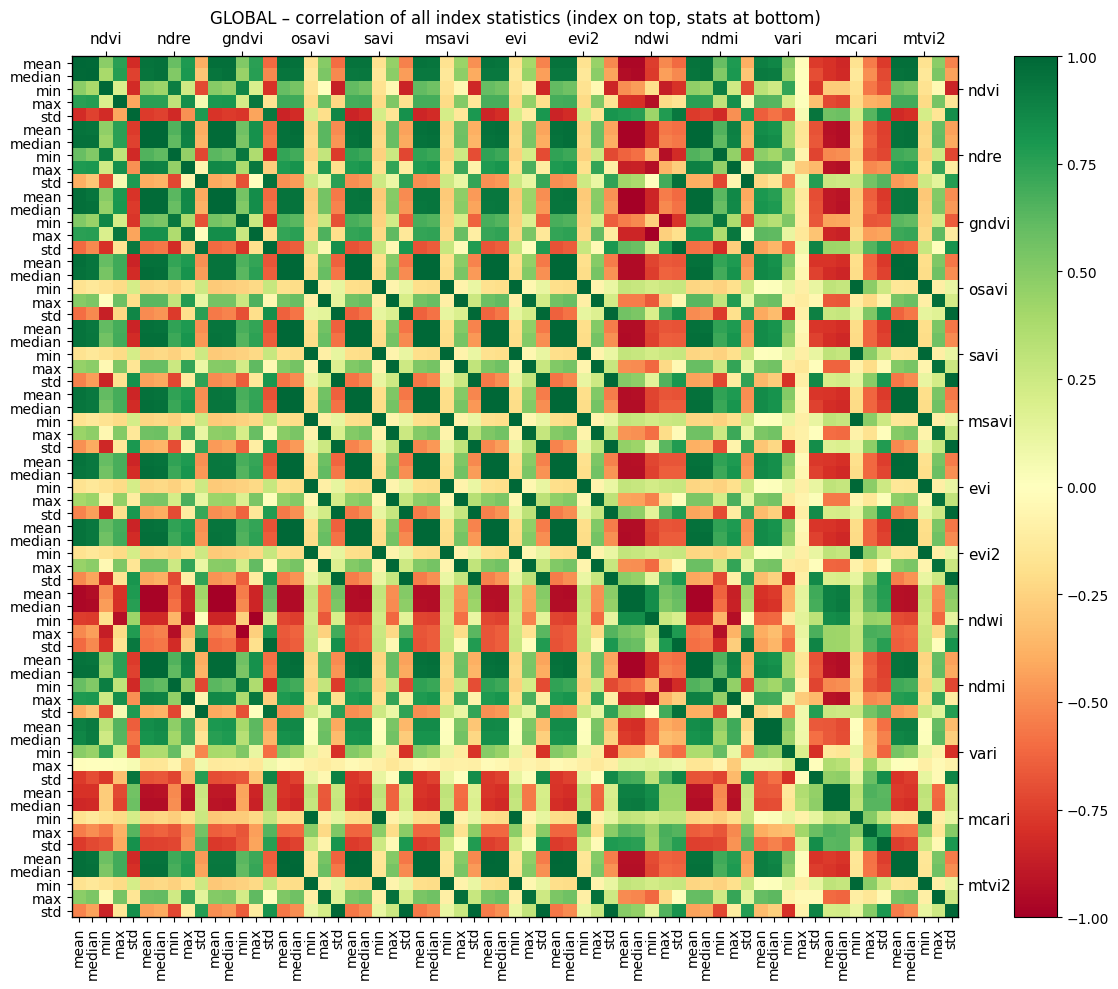


[biomass] columns used for correlation:
['ndvi_mean', 'ndvi_median', 'ndvi_min', 'ndvi_max', 'ndvi_std', 'gndvi_mean', 'gndvi_median', 'gndvi_min', 'gndvi_max', 'gndvi_std', 'osavi_mean', 'osavi_median', 'osavi_min', 'osavi_max', 'osavi_std', 'savi_mean', 'savi_median', 'savi_min', 'savi_max', 'savi_std', 'msavi_mean', 'msavi_median', 'msavi_min', 'msavi_max', 'msavi_std', 'evi_mean', 'evi_median', 'evi_min', 'evi_max', 'evi_std', 'evi2_mean', 'evi2_median', 'evi2_min', 'evi2_max', 'evi2_std']

[biomass] correlation matrix:
              ndvi_mean  ndvi_median  ndvi_min  ndvi_max  ndvi_std  \
ndvi_mean      1.000000     0.990329  0.482544  0.756963 -0.813994   
ndvi_median    0.990329     1.000000  0.385566  0.767782 -0.737637   
ndvi_min       0.482544     0.385566  1.000000  0.193760 -0.819998   
ndvi_max       0.756963     0.767782  0.193760  1.000000 -0.420438   
ndvi_std      -0.813994    -0.737637 -0.819998 -0.420438  1.000000   
gndvi_mean     0.963376     0.943127  0.492555  0

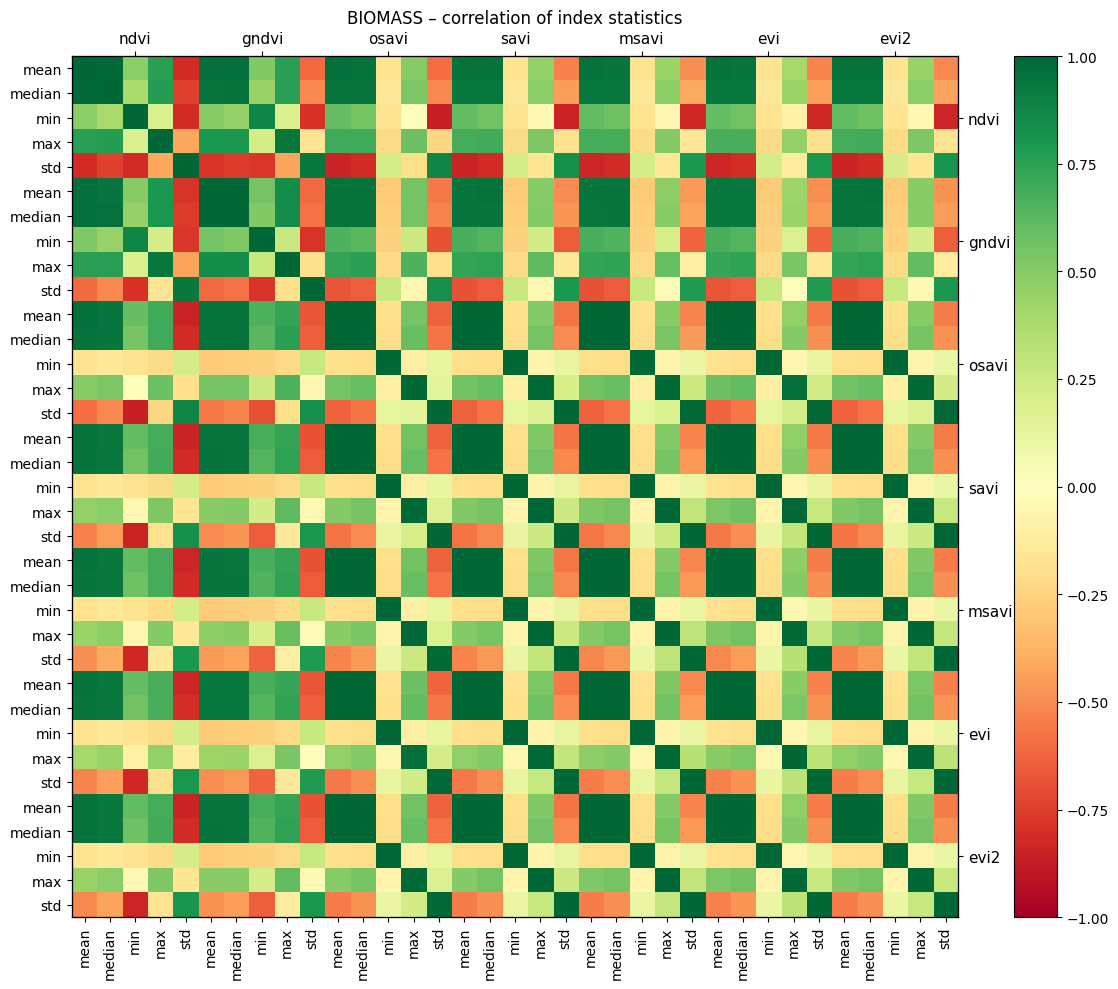


[water] columns used for correlation:
['ndwi_mean', 'ndwi_median', 'ndwi_min', 'ndwi_max', 'ndwi_std', 'ndmi_mean', 'ndmi_median', 'ndmi_min', 'ndmi_max', 'ndmi_std']

[water] correlation matrix:
             ndwi_mean  ndwi_median  ndwi_min  ndwi_max  ndwi_std  ndmi_mean  \
ndwi_mean     1.000000     0.996887  0.841166  0.549161  0.609301  -0.981081   
ndwi_median   0.996887     1.000000  0.841154  0.510134  0.579433  -0.979582   
ndwi_min      0.841166     0.841154  1.000000  0.265322  0.194924  -0.824843   
ndwi_max      0.549161     0.510134  0.265322  1.000000  0.786981  -0.569393   
ndwi_std      0.609301     0.579433  0.194924  0.786981  1.000000  -0.588623   
ndmi_mean    -0.981081    -0.979582 -0.824843 -0.569393 -0.588623   1.000000   
ndmi_median  -0.976994    -0.981589 -0.821871 -0.534445 -0.565806   0.996804   
ndmi_min     -0.628782    -0.587421 -0.359809 -0.933197 -0.814274   0.649012   
ndmi_max     -0.859855    -0.859110 -0.935049 -0.374105 -0.265890   0.890816   
ndm

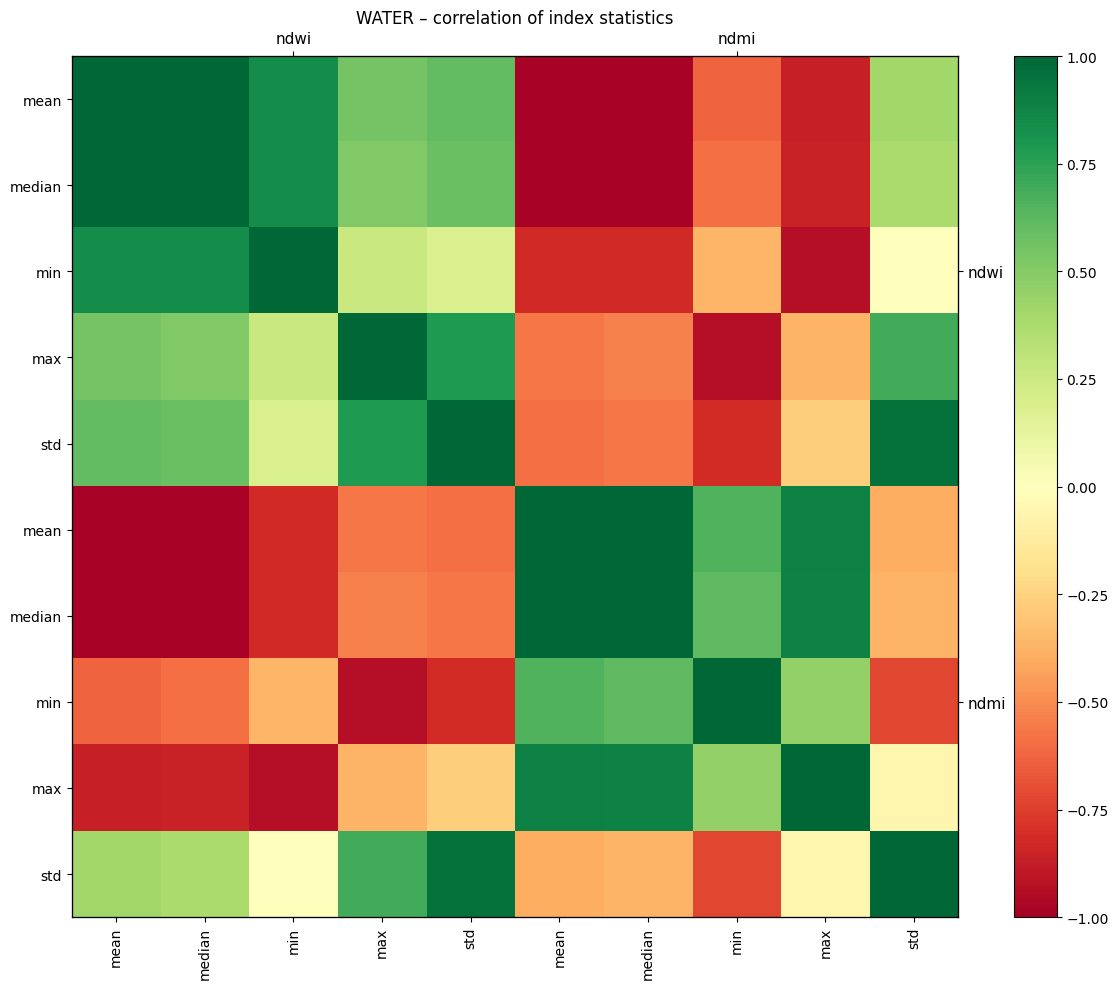


[vigor] columns used for correlation:
['ndre_mean', 'ndre_median', 'ndre_min', 'ndre_max', 'ndre_std', 'gndvi_mean', 'gndvi_median', 'gndvi_min', 'gndvi_max', 'gndvi_std', 'osavi_mean', 'osavi_median', 'osavi_min', 'osavi_max', 'osavi_std', 'mcari_mean', 'mcari_median', 'mcari_min', 'mcari_max', 'mcari_std', 'mtvi2_mean', 'mtvi2_median', 'mtvi2_min', 'mtvi2_max', 'mtvi2_std']

[vigor] correlation matrix:
              ndre_mean  ndre_median  ndre_min  ndre_max  ndre_std  \
ndre_mean      1.000000     0.996804  0.649012  0.890816 -0.394483   
ndre_median    0.996804     1.000000  0.610300  0.885356 -0.368275   
ndre_min       0.649012     0.610300  1.000000  0.453970 -0.725366   
ndre_max       0.890816     0.885356  0.453970  1.000000 -0.057173   
ndre_std      -0.394483    -0.368275 -0.725366 -0.057173  1.000000   
gndvi_mean     0.981081     0.976994  0.628782  0.859855 -0.413575   
gndvi_median   0.979582     0.981589  0.587421  0.859110 -0.380969   
gndvi_min      0.569393     0.5

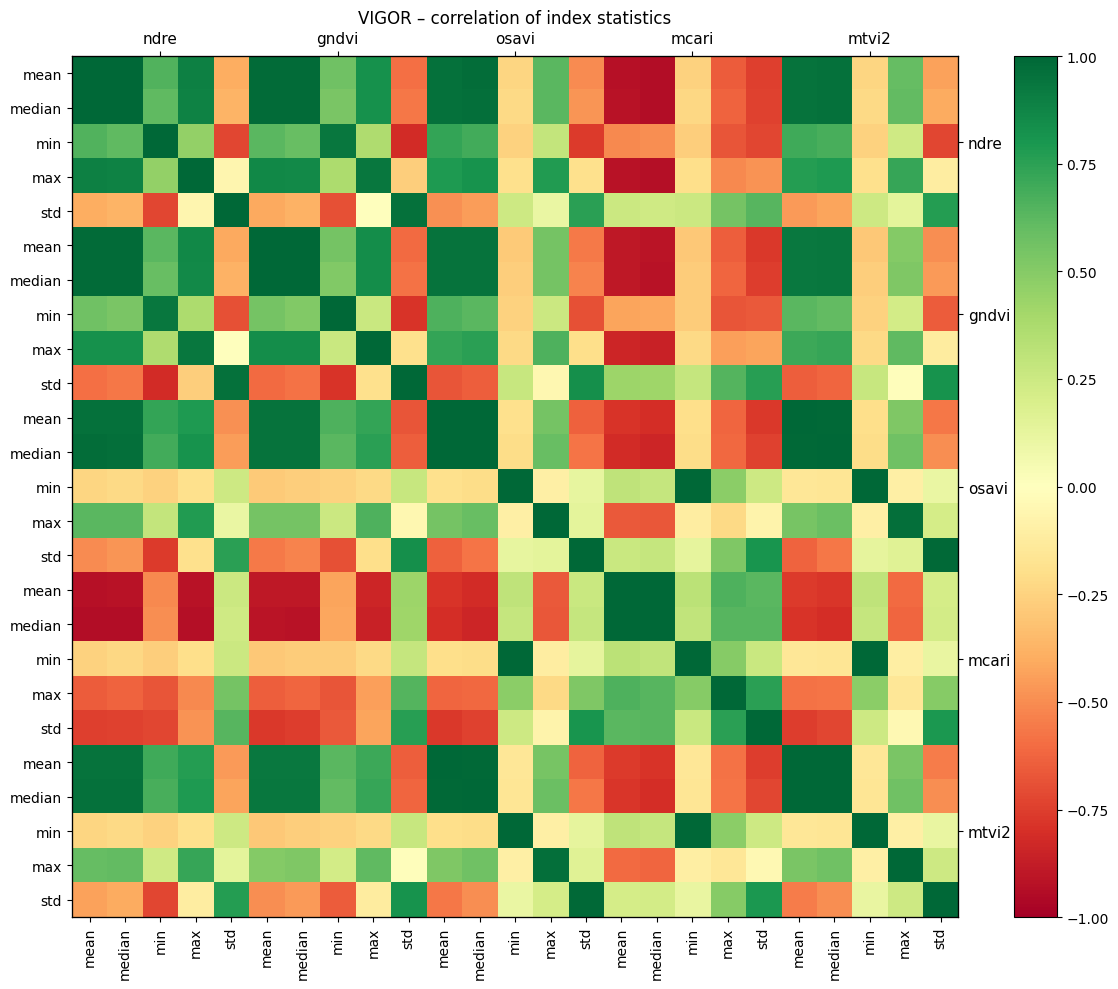


[rgb_only] columns used for correlation:
['vari_mean', 'vari_median', 'vari_min', 'vari_max', 'vari_std']

[rgb_only] correlation matrix:
             vari_mean  vari_median  vari_min  vari_max  vari_std
vari_mean     1.000000     0.995102  0.499490  0.074876 -0.658191
vari_median   0.995102     1.000000  0.438183  0.080515 -0.592467
vari_min      0.499490     0.438183  1.000000  0.191623 -0.800336
vari_max      0.074876     0.080515  0.191623  1.000000 -0.007887
vari_std     -0.658191    -0.592467 -0.800336 -0.007887  1.000000


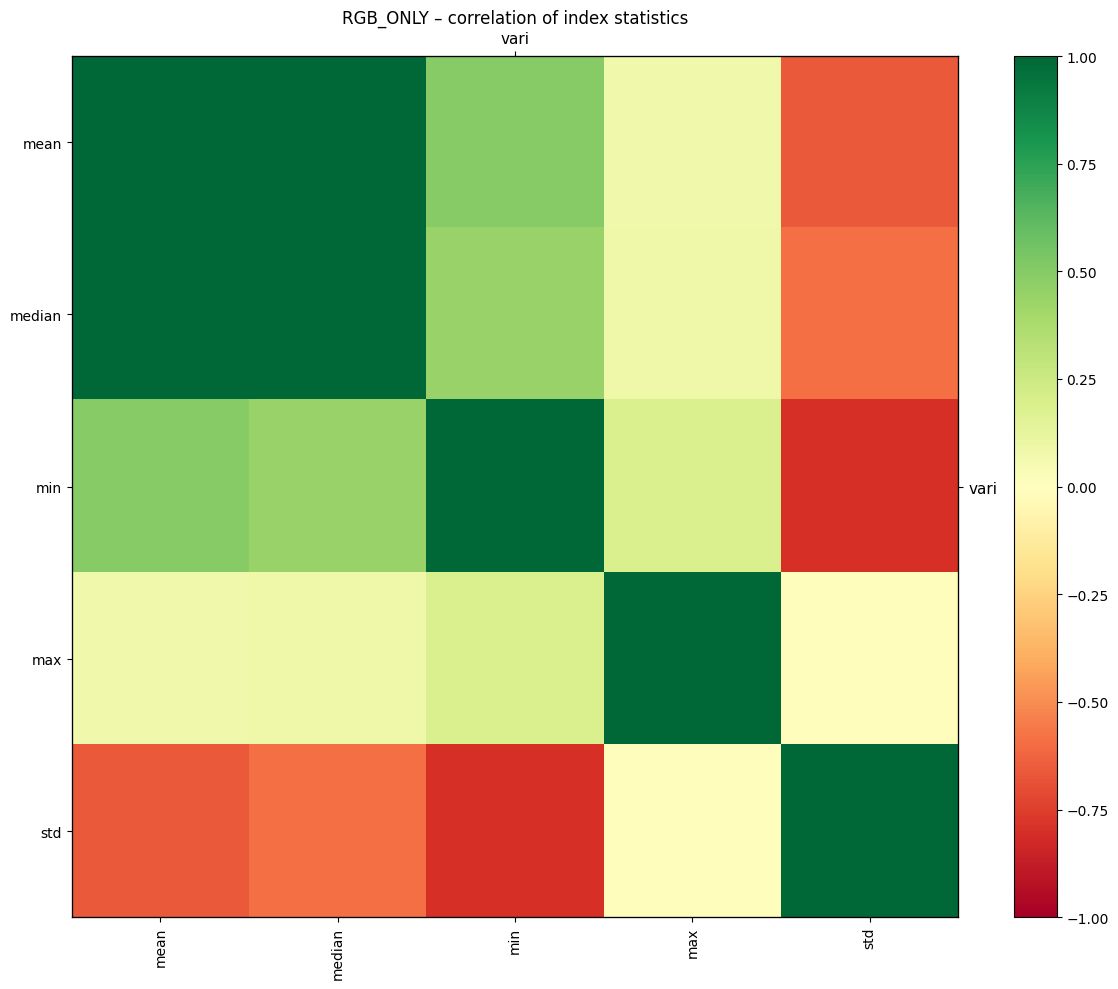

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD DATAFRAME
# ============================================================
DATA_DIR = Path("PBM_1.7.2_datasetsM172_RGB_MS").resolve()
CSV_PATH = DATA_DIR / "microplots_output" / "indices" / "microplots_indices_summary.csv"

df = pd.read_csv(CSV_PATH)
print("DataFrame loaded with shape:", df.shape)
print(df.head())

# ============================================================
# 2. HELPERS
# ============================================================
STATS_SUFFIXES = ["mean", "median", "min", "max", "std"]


def split_index_stat(col: str):
    """
    Split a column name like 'ndvi_mean' into ('ndvi', 'mean').
    If no '_' is found, returns (col, '').
    """
    if "_" in col:
        idx, stat = col.rsplit("_", 1)
        return idx, stat
    else:
        return col, ""


def get_index_stat_cols(df: pd.DataFrame, index_names=None):
    """
    Return all columns corresponding to index stats, optionally filtered by
    a list of index base names (e.g. ['ndvi','ndre']).

    Example columns: ndvi_mean, ndvi_median, ndre_std, ...
    """
    cols = []
    for col in df.columns:
        # Must end with one of the stat suffixes
        if not any(col.endswith("_" + s) for s in STATS_SUFFIXES):
            continue

        if index_names is None:
            cols.append(col)
        else:
            for idx in index_names:
                if col.startswith(idx + "_"):
                    cols.append(col)
                    break
    return cols


def compute_correlation(df: pd.DataFrame, columns) -> pd.DataFrame:
    """
    Compute a correlation matrix from the given DataFrame restricted to 'columns'.
    Only numeric columns are kept.
    """
    sub = df[columns]
    # Explicitly keep only numeric columns (avoids numeric_only issues)
    sub_num = sub.select_dtypes(include=[np.number])
    if sub_num.shape[1] < 2:
        return pd.DataFrame()
    return sub_num.corr()

def plot_correlation_heatmap_twolevel_axes(
    corr: pd.DataFrame,
    title: str,
    cmap: str = "RdYlGn",
):
    """
    Plot a correlation heatmap with:
      - Bottom axis: stats (mean, min, max, ...)
      - Top axis: index names (grouped)
      - Left axis: stats
      - Right axis: index names (grouped)
    """

    if corr.empty:
        print(f"[{title}] Correlation matrix is empty, nothing to plot.")
        return

    # Work with the actual order in corr
    cols = list(corr.columns)

    # Parse index+stat from column names
    idx_names = []
    stats = []
    for c in cols:
        idx, stat = split_index_stat(c)
        idx_names.append(idx)
        stats.append(stat if stat else idx)

    fig, ax = plt.subplots(figsize=(12, 10))

    # Heatmap
    cax = ax.imshow(corr.values, interpolation="nearest", cmap=cmap, vmin=-1, vmax=1)
    fig.colorbar(cax, ax=ax)

    # IMPORTANT: avoid aspect='equal' with shared axes
    ax.set_aspect("auto")

    n = len(cols)
    positions = np.arange(n)

    # ---------------------------------------------------------
    # 1) Bottom X-axis → stats
    # ---------------------------------------------------------
    ax.set_xticks(positions)
    ax.set_xticklabels(stats, rotation=90)

    # Left Y-axis → stats (same order as columns)
    ax.set_yticks(positions)
    ax.set_yticklabels(stats)

    # ---------------------------------------------------------
    # Compute grouping of contiguous indices for top & right
    # ---------------------------------------------------------
    group_labels = []
    group_centers = []

    current = idx_names[0]
    start = 0

    for i in range(1, n):
        if idx_names[i] != current:
            # group ends at i-1
            center = (start + (i - 1)) / 2
            group_labels.append(current)
            group_centers.append(center)

            current = idx_names[i]
            start = i

    # Last group
    center = (start + (n - 1)) / 2
    group_labels.append(current)
    group_centers.append(center)

    # ---------------------------------------------------------
    # 2) Top X-axis → index names (grouped)
    # ---------------------------------------------------------
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    ax_top.set_xticks(group_centers)
    ax_top.set_xticklabels(group_labels, rotation=0, fontsize=11)

    # ---------------------------------------------------------
    # 3) Right Y-axis → index names (grouped)
    # ---------------------------------------------------------
    ax_right = ax.twinx()
    ax_right.set_ylim(ax.get_ylim())
    ax_right.set_yticks(group_centers)
    ax_right.set_yticklabels(group_labels, fontsize=11)

    ax.set_title(title)
    plt.tight_layout()
    plt.show()



# ============================================================
# 3. DEFINE INDEX CATEGORIES (OPTIONAL)
# ============================================================
# These are the index *base names* you defined in INDEX_FUNCS earlier

CATEGORIES = {
    # Biomass / LAI / general greenness
    "biomass": [
        "ndvi",
        "evi",
        "evi2",
        "savi",
        "msavi",
        "osavi",
        "gndvi",
    ],

    # Water-related indices
    "water": [
        "ndwi",
        "ndmi",
    ],

    # Chlorophyll / canopy vigor / structure
    "vigor": [
        "ndre",
        "mcari",
        "mtvi2",
        "gndvi",
        "osavi",
    ],

    # Indices that can be computed from RGB only
    "rgb_only": [
        "vari",
    ],
}


# ============================================================
# 4. GLOBAL CORRELATION (ALL INDEX STATS)
# ============================================================
all_stat_cols = get_index_stat_cols(df, index_names=None)
all_stat_cols = [c for c in all_stat_cols if c in df.columns]

print("\nAll index-stat columns used for GLOBAL correlation:")
print(all_stat_cols)

if len(all_stat_cols) >= 2:
    corr_global = compute_correlation(df, columns=all_stat_cols)
    print("\nGLOBAL correlation matrix (all index stats):")
    print(corr_global)

    plot_correlation_heatmap_twolevel_axes(
        corr_global,
        title="GLOBAL – correlation of all index statistics (index on top, stats at bottom)",
        cmap="RdYlGn",
    )
else:
    print("Not enough columns for GLOBAL correlation.")


# ============================================================
# 5. CATEGORY-SPECIFIC CORRELATIONS (BIOMASS, WATER, VIGOR, RGB-ONLY)
# ============================================================
for cat_name, idx_list in CATEGORIES.items():
    cat_cols = get_index_stat_cols(df, index_names=idx_list)
    cat_cols = [c for c in cat_cols if c in df.columns]

    if len(cat_cols) < 2:
        print(f"\n[{cat_name}] Not enough columns ({len(cat_cols)}) – skipping.")
        continue

    print(f"\n[{cat_name}] columns used for correlation:")
    print(cat_cols)

    corr_cat = compute_correlation(df, columns=cat_cols)
    print(f"\n[{cat_name}] correlation matrix:")
    print(corr_cat)

    plot_correlation_heatmap_twolevel_axes(
        corr_cat,
        title=f"{cat_name.upper()} – correlation of index statistics",
        cmap="RdYlGn",
    )


Detected indices: ['evi', 'evi2', 'gndvi', 'mcari', 'msavi', 'mtvi2', 'ndmi', 'ndre', 'ndvi', 'ndwi', 'osavi', 'savi', 'vari']


<Figure size 3000x1000 with 0 Axes>

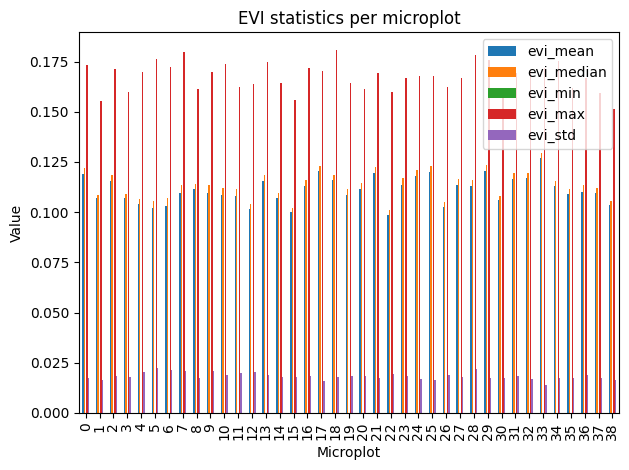

<Figure size 3000x1000 with 0 Axes>

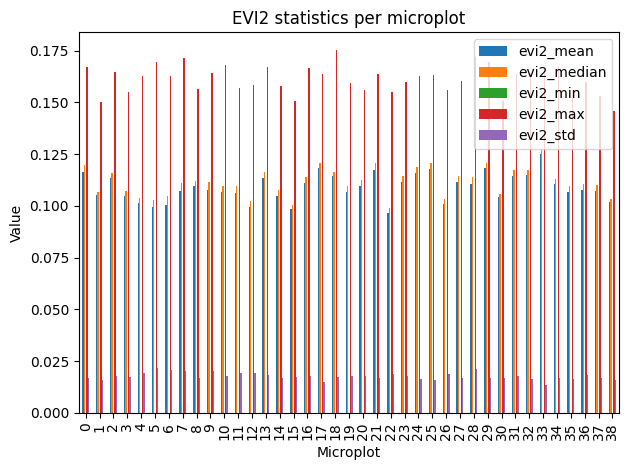

<Figure size 3000x1000 with 0 Axes>

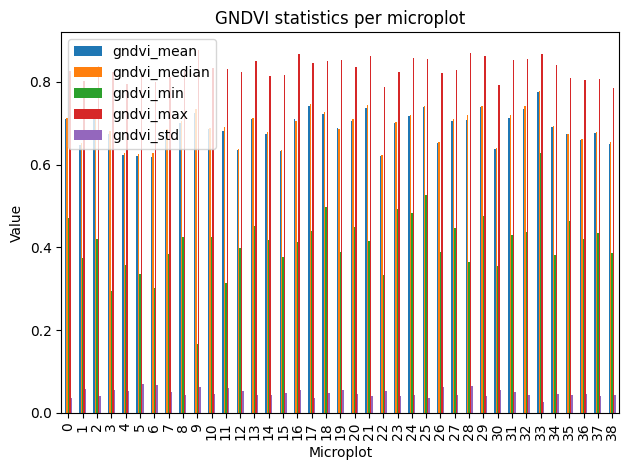

<Figure size 3000x1000 with 0 Axes>

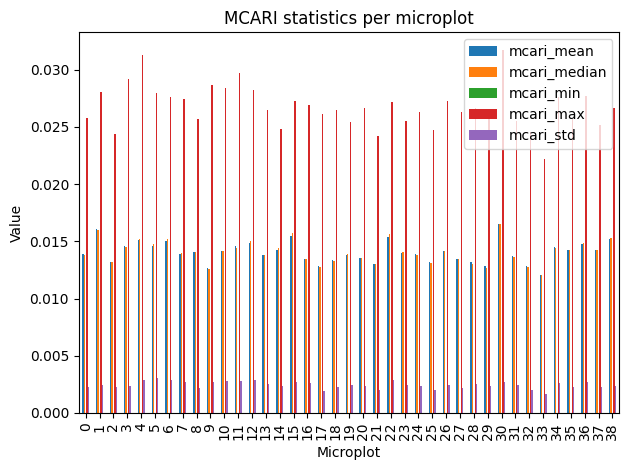

<Figure size 3000x1000 with 0 Axes>

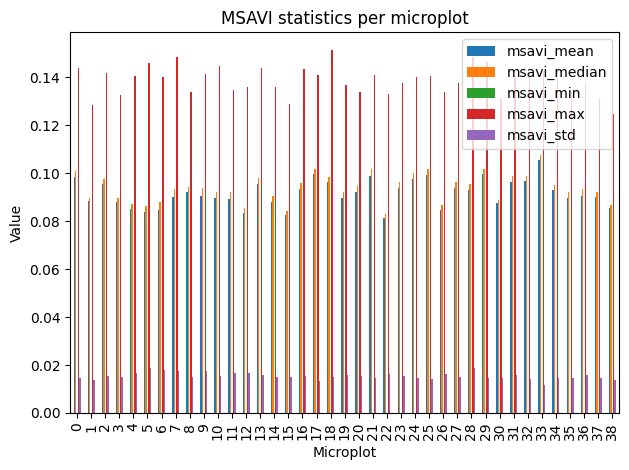

<Figure size 3000x1000 with 0 Axes>

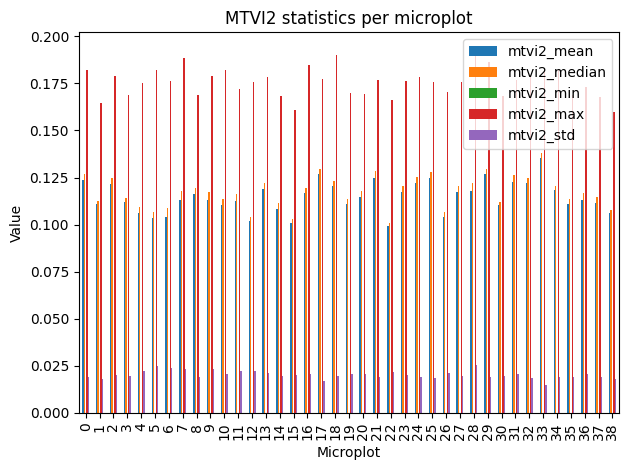

<Figure size 3000x1000 with 0 Axes>

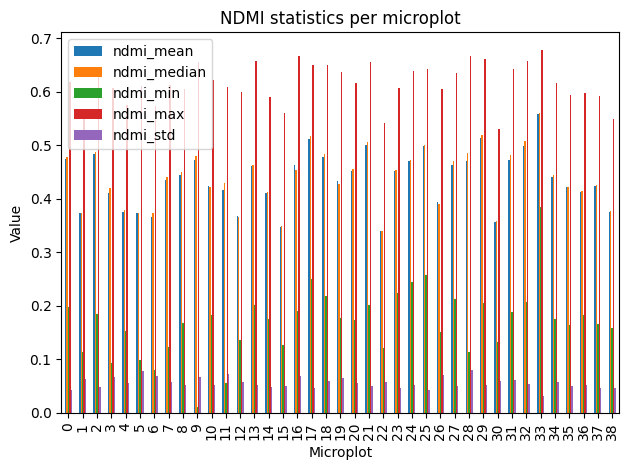

<Figure size 3000x1000 with 0 Axes>

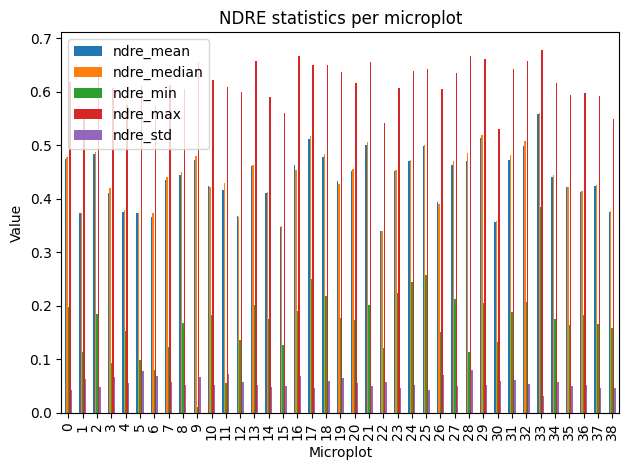

<Figure size 3000x1000 with 0 Axes>

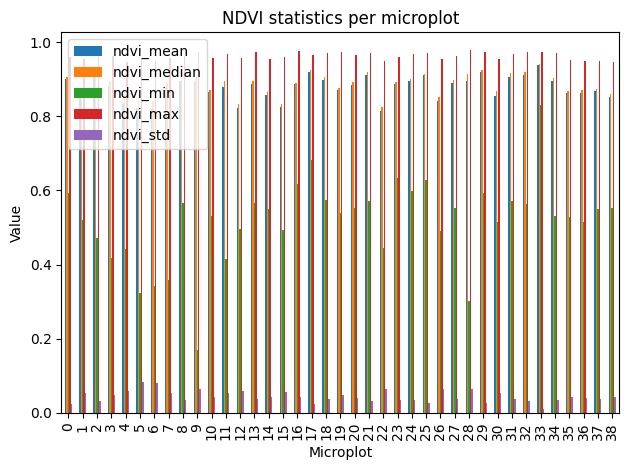

<Figure size 3000x1000 with 0 Axes>

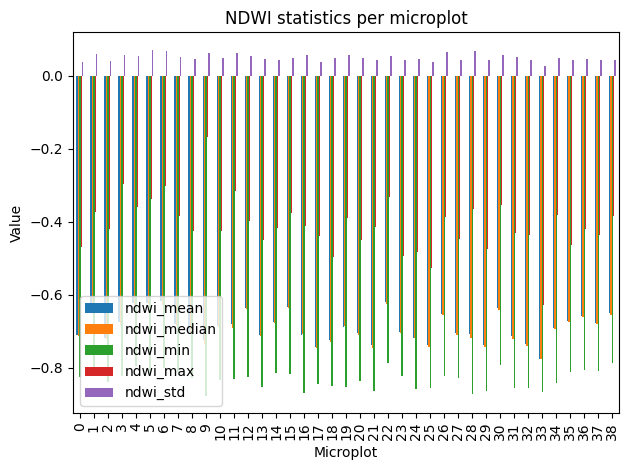

<Figure size 3000x1000 with 0 Axes>

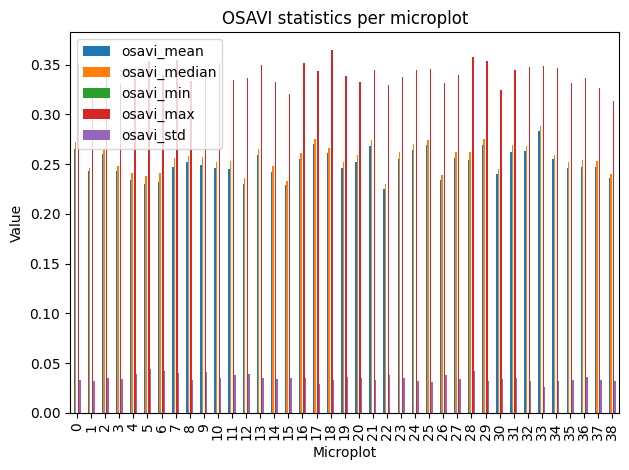

<Figure size 3000x1000 with 0 Axes>

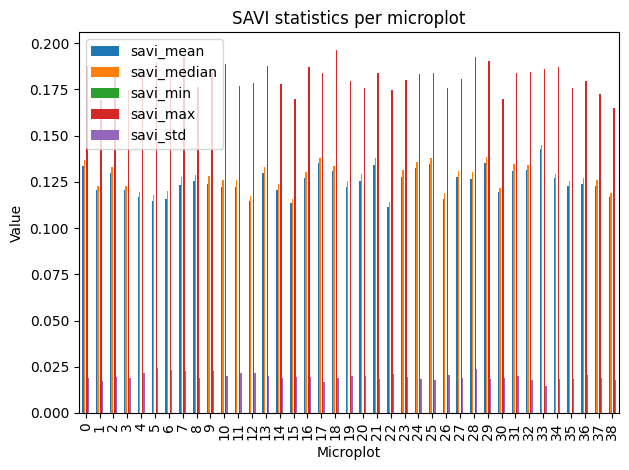

<Figure size 3000x1000 with 0 Axes>

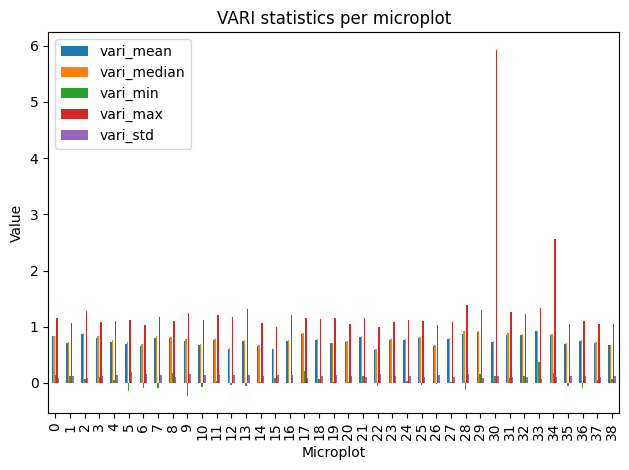

In [7]:
import matplotlib.pyplot as plt

def plot_index_stats(df):
    """
    Automatically plot all index statistics (mean, median, min, max, std)
    for each index present in the DataFrame.

    df must contain columns such as:
    ndvi_mean, ndvi_median, ndvi_min, ndvi_max, ndvi_std, ...
    """

    # Detect stats and index names
    stats = ["mean", "median", "min", "max", "std"]
    index_names = set()

    for col in df.columns:
        for s in stats:
            if col.endswith("_" + s):
                index_names.add(col.replace("_" + s, ""))

    index_names = sorted(list(index_names))

    print("Detected indices:", index_names)

    # Plot each index
    for idx in index_names:
        # columns like ndvi_mean, ndvi_median, ...
        cols = [f"{idx}_{s}" for s in stats if f"{idx}_{s}" in df.columns]
        data = df[cols]

        plt.figure(figsize=(30, 10))
        data.plot(kind="bar")
        plt.title(f"{idx.upper()} statistics per microplot")
        plt.xlabel("Microplot")
        plt.ylabel("Value")
        plt.tight_layout()
        plt.show()


plot_index_stats(df)